In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. LOAD THE CHAMPION MODEL
# This is the "brain" you trained in Stage 4/5
model = joblib.load('Perovskite_Regressor_Model.joblib')

# 2. LOAD THE VIRTUAL LIBRARY 
# This is the file I just generated for you with 350 hypothetical materials
vhts_df2 = pd.read_csv('vscode-Virtual_Perovskite_Library.csv')

# 3. DEFINE THE 24 FEATURES
# These must match the exact order and names used during model training
features = [
    'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
    'tolerance_factor', 'octahedral_factor', 'volume', 'density', 
    'chi_diff_BX', 'r_ratio_BX', 'bond_len_BX', 'inv_bond_sq', 
    'stability_index', 'lattice_strain', 'packing_index', 
    'PC1_Size', 'PC2_Shape', 'Stability_Tag', 'B_site_encoded'
]

X_virtual = vhts_df[features]
print(f"✅ Successfully loaded 350 hypothetical materials and the Champion Model.")

✅ Successfully loaded 350 hypothetical materials and the Champion Model.


In [10]:
# 1. PREDICT BANDGAPS FOR ALL HYPOTHETICAL MATERIALS
vhts_df2['Predicted_BG'] = model.predict(X_virtual)

# 2. FILTER FOR "ELITE" MATERIALS
# Criteria: 
# - Lead-Free (B_site != 'Pb')
# - Stable (Stability_Tag == 1)
# - Solar Ready Bandgap (1.1 eV to 1.7 eV)
elite_candidates2 = vhts_df2[
    (vhts_df2['B_site'] != 'Pb') & 
    (vhts_df2['Stability_Tag'] == 1) & 
    (vhts_df2['Predicted_BG'] >= 1.1) & 
    (vhts_df2['Predicted_BG'] <= 1.7)
].copy()

print(f"🌟 DISCOVERY: Found {len(elite_candidates2)} new Lead-Free stable solar candidates!")
# Display the top 10 new materials
print(elite_candidates2[['formula', 'Predicted_BG', 'tolerance_factor']].sort_values(by='Predicted_BG').head(10))

# Save the discovery list for your dissertation appendix
elite_candidates2.to_csv('Elite_Solar_Discoveries2.csv', index=False)

🌟 DISCOVERY: Found 49 new Lead-Free stable solar candidates!
     formula  Predicted_BG  tolerance_factor
282  FASrCl3      1.106785          1.026369
122   KZnCl3      1.140669          0.956674
57   RbSnCl3      1.211199          0.857762
230   MASrI3      1.212168          0.914218
285   FACaI3      1.213953          1.045192
280   FASrI3      1.220148          0.989531
235   MACaI3      1.247584          0.965643
172  NaZnCl3      1.301962          0.887350
80    RbSrI3      1.313723          0.820077
30    CsSrI3      1.313723          0.853549


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


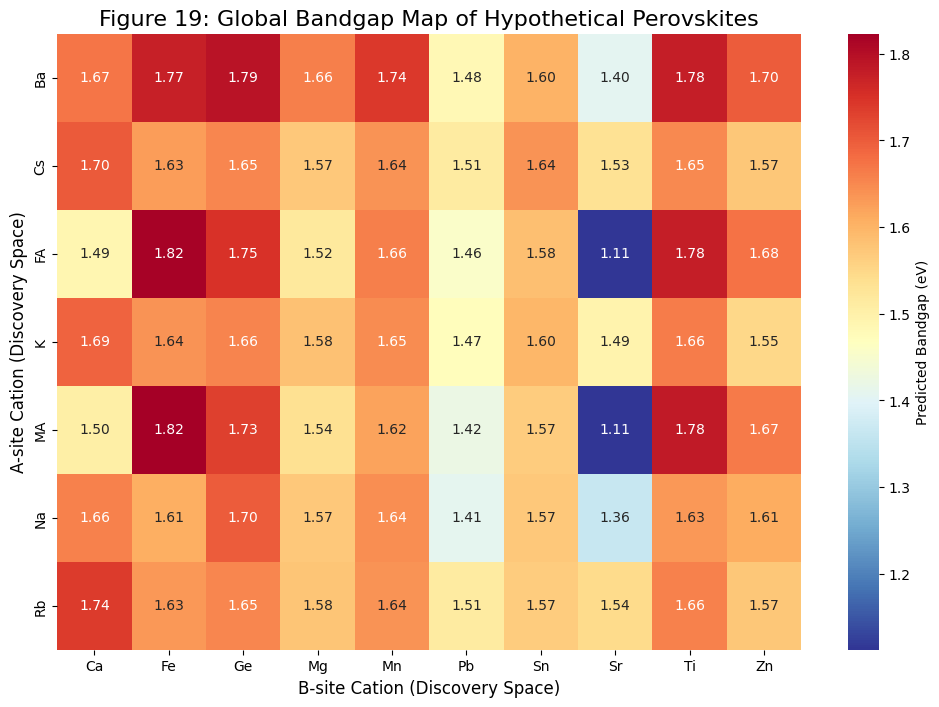

In [11]:
# Create a pivot table for the heatmap
pivot_bg2 = vhts_df2.pivot_table(index='A_site', columns='B_site', values='Predicted_BG', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_bg2, annot=True, cmap='RdYlBu_r', fmt=".2f", cbar_kws={'label': 'Predicted Bandgap (eV)'})
plt.title("Figure 19: Global Bandgap Map of Hypothetical Perovskites", fontsize=16)
plt.xlabel("B-site Cation (Discovery Space)", fontsize=12)
plt.ylabel("A-site Cation (Discovery Space)", fontsize=12)
plt.show()